> **Solucion.** Notebook original del curso con los `TODO` completados y verificados: todos los `assert` de las celdas de prueba pasan y el notebook corre de principio a fin (`Restart & Run All`). Enunciados, visualizaciones y pruebas quedan intactos.
>
> Nicolas Rodriguez

# Taller de código 1: algoritmos de búsqueda

Implementarás **BFS, UCS y A\*** sobre el mismo grafo. El objetivo no es solo encontrar una ruta, sino comparar:

- ruta encontrada;
- costo total;
- número y orden de nodos expandidos.

Tiempo estimado: **60–75 minutos**.

## Problema

Un agente debe viajar desde `S` hasta `G`. Las aristas tienen costos y cada nodo posee una heurística estimada hacia la meta.

| Nodo | $h(n)$ |
|---|---:|
| S | 6 |
| A | 4 |
| B | 3 |
| C | 5 |
| D | 2 |
| G | 0 |

In [1]:
from collections import deque
import heapq
import itertools
import pandas as pd
import matplotlib.pyplot as plt

graph = {
    "S": [("A", 2), ("B", 5)],
    "A": [("C", 2), ("D", 4)],
    "B": [("D", 1)],
    "C": [("G", 5)],
    "D": [("G", 2)],
    "G": [],
}

heuristic = {"S": 6, "A": 4, "B": 3, "C": 5, "D": 2, "G": 0}

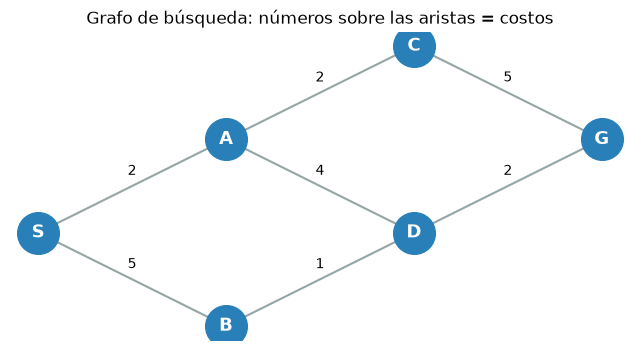

In [2]:
positions = {"S": (0, 1), "A": (1, 2), "B": (1, 0), "C": (2, 3), "D": (2, 1), "G": (3, 2)}

plt.figure(figsize=(8, 4))
for source, neighbors in graph.items():
    x1, y1 = positions[source]
    for target, cost in neighbors:
        x2, y2 = positions[target]
        plt.plot([x1, x2], [y1, y2], color="#95a5a6", zorder=1)
        plt.text((x1+x2)/2, (y1+y2)/2 + 0.12, str(cost), ha="center")
for node, (x, y) in positions.items():
    plt.scatter(x, y, s=900, color="#2980b9", zorder=2)
    plt.text(x, y, node, color="white", ha="center", va="center", fontsize=13, weight="bold")
plt.axis("off")
plt.title("Grafo de búsqueda: números sobre las aristas = costos")
plt.show()

## Actividad 1 — Reconstruir una ruta

In [3]:
def reconstruct_path(parent, goal):
    """Reconstruye la ruta inicio -> goal siguiendo los padres hasta None."""
    path = []
    node = goal
    while node is not None:
        path.append(node)
        node = parent[node]
    path.reverse()
    return path

In [4]:
# Prueba
example_parent = {"S": None, "A": "S", "D": "A", "G": "D"}
assert reconstruct_path(example_parent, "G") == ["S", "A", "D", "G"]
print("Prueba 1 superada.")

Prueba 1 superada.


## Actividad 2 — BFS

Completa BFS usando una cola FIFO. Ignora los costos al decidir qué nodo expandir, pero calcula el costo de la ruta encontrada al final.

In [5]:
def path_cost(graph, path):
    total = 0
    for source, target in zip(path, path[1:]):
        total += dict(graph[source])[target]
    return total


def bfs(graph, start, goal):
    """BFS con deque (cola FIFO). Devuelve path, cost y expanded_order."""
    frontier = deque([start])
    parent = {start: None}
    expanded = []
    while frontier:
        node = frontier.popleft()
        expanded.append(node)
        if node == goal:
            path = reconstruct_path(parent, goal)
            return path, path_cost(graph, path), expanded
        for nxt, _ in graph[node]:
            if nxt not in parent:                 # evita revisitar
                parent[nxt] = node
                frontier.append(nxt)
    return None, float("inf"), expanded

In [6]:
path_bfs, cost_bfs, expanded_bfs = bfs(graph, "S", "G")
assert path_bfs[0] == "S" and path_bfs[-1] == "G"
assert len(path_bfs) == 4
print(path_bfs, cost_bfs, expanded_bfs)

['S', 'A', 'C', 'G'] 9 ['S', 'A', 'B', 'C', 'D', 'G']


## Actividad 3 — Uniform Cost Search

Usa una cola de prioridad ordenada por $g(n)$. Si encuentras una ruta más barata hacia un nodo, actualiza su mejor costo y su padre.

In [7]:
def uniform_cost_search(graph, start, goal):
    """UCS con heapq. Prioridad = g(n). Prueba de meta al EXTRAER (no al generar).
    Devuelve path, cost y expanded_order."""
    counter = itertools.count()                    # desempata en el heap
    frontier = [(0, next(counter), start)]
    best_g = {start: 0}
    parent = {start: None}
    expanded = []
    while frontier:
        g, _, node = heapq.heappop(frontier)
        if g > best_g.get(node, float("inf")):     # entrada obsoleta
            continue
        expanded.append(node)
        if node == goal:
            return reconstruct_path(parent, goal), g, expanded
        for nxt, w in graph[node]:
            ng = g + w
            if ng < best_g.get(nxt, float("inf")):
                best_g[nxt] = ng
                parent[nxt] = node
                heapq.heappush(frontier, (ng, next(counter), nxt))
    return None, float("inf"), expanded

In [8]:
path_ucs, cost_ucs, expanded_ucs = uniform_cost_search(graph, "S", "G")
assert cost_ucs == 8
assert path_ucs[0] == "S" and path_ucs[-1] == "G"
print(path_ucs, cost_ucs, expanded_ucs)

['S', 'A', 'D', 'G'] 8 ['S', 'A', 'C', 'B', 'D', 'G']


## Actividad 4 — A*

Implementa A* usando $f(n)=g(n)+h(n)$. La heurística se usa para ordenar la frontera, pero el costo acumulado real sigue siendo $g(n)$.

In [9]:
def a_star(graph, heuristic, start, goal):
    """A* = UCS con prioridad f(n) = g(n) + h(n). Con h admisible es optimo.
    Devuelve path, cost y expanded_order."""
    counter = itertools.count()
    frontier = [(heuristic[start], next(counter), start)]
    best_g = {start: 0}
    parent = {start: None}
    expanded = []
    while frontier:
        _, _, node = heapq.heappop(frontier)
        g = best_g[node]
        expanded.append(node)
        if node == goal:
            return reconstruct_path(parent, goal), g, expanded
        for nxt, w in graph[node]:
            ng = g + w
            if ng < best_g.get(nxt, float("inf")):
                best_g[nxt] = ng
                parent[nxt] = node
                heapq.heappush(frontier, (ng + heuristic[nxt], next(counter), nxt))
    return None, float("inf"), expanded

In [10]:
path_astar, cost_astar, expanded_astar = a_star(graph, heuristic, "S", "G")
assert cost_astar == 8
assert path_astar[0] == "S" and path_astar[-1] == "G"
print(path_astar, cost_astar, expanded_astar)

['S', 'A', 'D', 'G'] 8 ['S', 'A', 'B', 'D', 'G']


## Actividad 5 — Comparación

In [11]:
results = pd.DataFrame([
    {"algorithm": "BFS", "path": path_bfs, "cost": cost_bfs, "expanded": len(expanded_bfs)},
    {"algorithm": "UCS", "path": path_ucs, "cost": cost_ucs, "expanded": len(expanded_ucs)},
    {"algorithm": "A*", "path": path_astar, "cost": cost_astar, "expanded": len(expanded_astar)},
])
results

,algorithm,path,cost,expanded
0,BFS,"[S, A, C, G]",9,6
1,UCS,"[S, A, D, G]",8,6
2,A*,"[S, A, D, G]",8,5


## Preguntas de análisis

1. ¿Por qué BFS puede devolver una ruta con mayor costo aunque tenga el mismo número de aristas?
2. ¿Qué diferencia observas entre el orden de expansión de UCS y A*?
3. Cambia `heuristic["A"]` a `20`. ¿La heurística sigue siendo admisible? ¿Qué ocurre con el resultado?
4. ¿En qué parte del código se implementa realmente la estrategia de búsqueda: al generar sucesores o al extraer de la frontera?

## Checklist

- [ ] Reconstruí rutas correctamente.
- [ ] Implementé BFS con FIFO.
- [ ] Implementé UCS con prioridad $g(n)$.
- [ ] Implementé A* con prioridad $g(n)+h(n)$.
- [ ] Comparé costo y nodos expandidos.